# Effects Dev Notebook

Tuning each of the 5 effects against 4 fixed test images before locking anything
into `src/effects.py`:

- `portrait.jpg` — synthetic face, flat shading, clean edges
- `landscape.jpg` — sunset gradient, layered mountains, water reflection
- `detail.jpg` — brick texture, lots of fine edges
- `face.jpg` — a real photo, to see how each effect behaves on real skin
  texture, lighting and JPEG noise (the synthetic images don't have any noise,
  so this is what actually drives most of the parameter choices below)

Each section below: implement the effect, run a small parameter sweep, look at
the results side by side, and write down why the chosen values won.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")

def load(name):
    img = cv2.imread(str(DATA_DIR / name))
    if img is None:
        raise FileNotFoundError(f"Couldn't find {name} in {DATA_DIR} - drop it in there first.")
    return img

def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

TEST_IMAGES = ["portrait.jpg", "landscape.jpg", "detail.jpg", "face.jpg"]

def show_row(images, titles, figsize_per=3.2):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per * n, figsize_per))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(bgr2rgb(img) if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_grid(rows_of_images, row_labels, col_labels, figsize_per=3.0):
    n_rows = len(rows_of_images)
    n_cols = len(rows_of_images[0])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per * n_cols, figsize_per * n_rows))
    if n_rows == 1:
        axes = [axes]
    for r in range(n_rows):
        for c in range(n_cols):
            ax = axes[r][c] if n_rows > 1 else axes[c]
            img = rows_of_images[r][c]
            ax.imshow(bgr2rgb(img) if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
            if r == 0:
                ax.set_title(col_labels[c], fontsize=10)
            if c == 0:
                ax.set_ylabel(row_labels[r], fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()


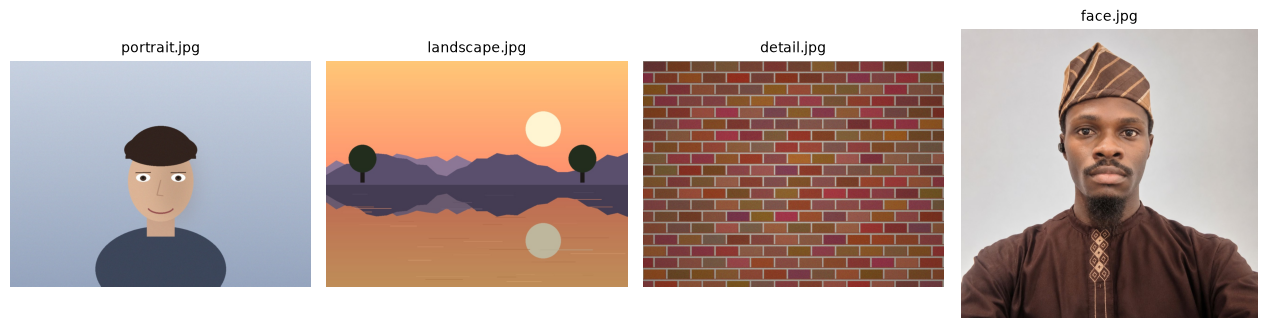

In [2]:
images = {name: load(name) for name in TEST_IMAGES}
show_row(list(images.values()), list(images.keys()))


## 1. Grayscale

The trivial version is just `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)`. The
question is whether plain grayscale is good enough, or whether a contrast
boost is worth adding.

Plain grayscale just maps each pixel's RGB to luminance. On a well-lit, high
contrast image this is fine. On a photo with dark skin tones and dark
clothing against a light background (like `face.jpg`), most of the subject
compresses into a narrow dark band and detail gets crushed.

`cv2.createCLAHE` (Contrast Limited Adaptive Histogram Equalization) fixes
this by equalizing contrast in local tiles rather than globally, so it
brightens detail in dark regions without blowing out the already-bright
background. `clipLimit` caps how aggressively it can boost contrast in any
one tile (prevents noise amplification), `tileGridSize` controls how local
the adaptation is (8x8 is a good default - small enough to adapt per-region,
large enough to stay stable).

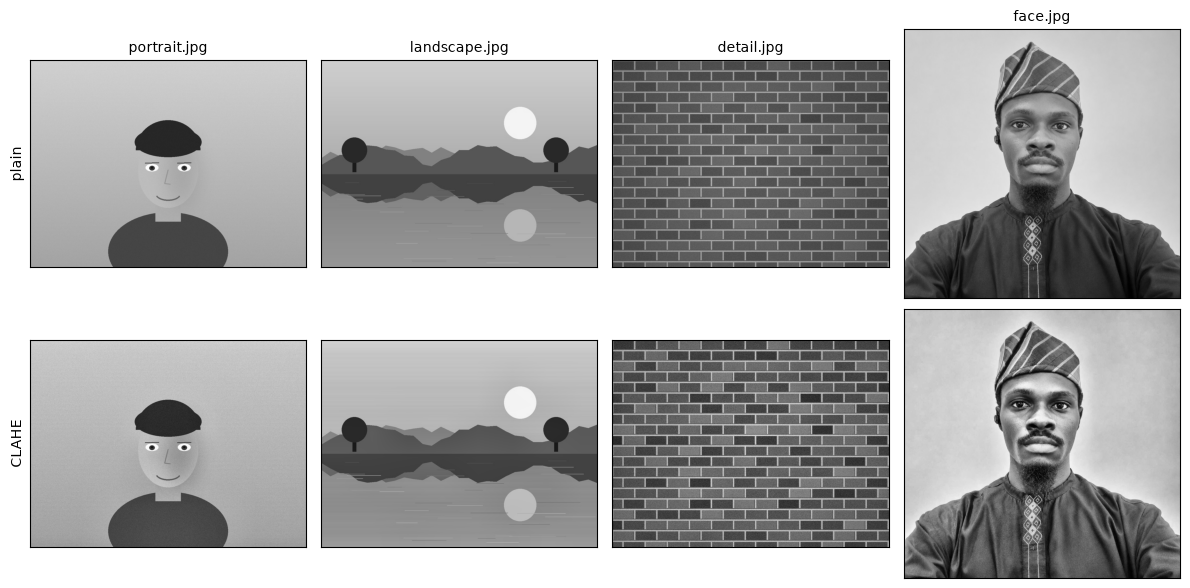

In [3]:
def grayscale_plain(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

def grayscale(img, clip_limit=2.0, tile=8):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    gray = clahe.apply(gray)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

rows = [
    [grayscale_plain(images[n]) for n in TEST_IMAGES],
    [grayscale(images[n]) for n in TEST_IMAGES],
]
show_grid(rows, row_labels=["plain", "CLAHE"], col_labels=TEST_IMAGES)


**Decision: CLAHE grayscale, `clip_limit=2.0`, `tile=8x8`.**

Side by side, plain grayscale on `face.jpg` loses almost all detail in the
dark shirt and the shaded side of the face. CLAHE recovers that detail (you
can see fabric folds and beard texture that plain grayscale just turns into a
flat dark blob), and on the already-bright `landscape.jpg` the difference is
minor, so there's no real downside to using it everywhere.

## 2. Pencil sketch

`cv2.pencilSketch` (from `opencv-contrib-python`) does edge-preserving
smoothing plus a detail-enhancing blend to fake a graphite look. It returns
both a grayscale and a color sketch - using the grayscale one here.

Parameters:
- `sigma_s` (0-200): spatial scale of the smoothing. Higher = strokes react
  to larger regions, "wider pencil".
  - `sigma_r` (0-1): range/edge sensitivity. Lower = only strong edges get
  drawn as lines, more of the image stays flat white. Higher = more tonal
  detail gets rendered as shading.
- `shade_factor` (0-0.1ish): overall darkness of the shading blend.

The first pass (default-ish values) looked fine on the synthetic images but
was full of speckled dot-noise on `face.jpg` — real photos have sensor noise
that `pencilSketch` was treating as texture to draw. Adding a small Gaussian
blur *before* the sketch call (kernel size 3) fixed this without softening
real edges away.

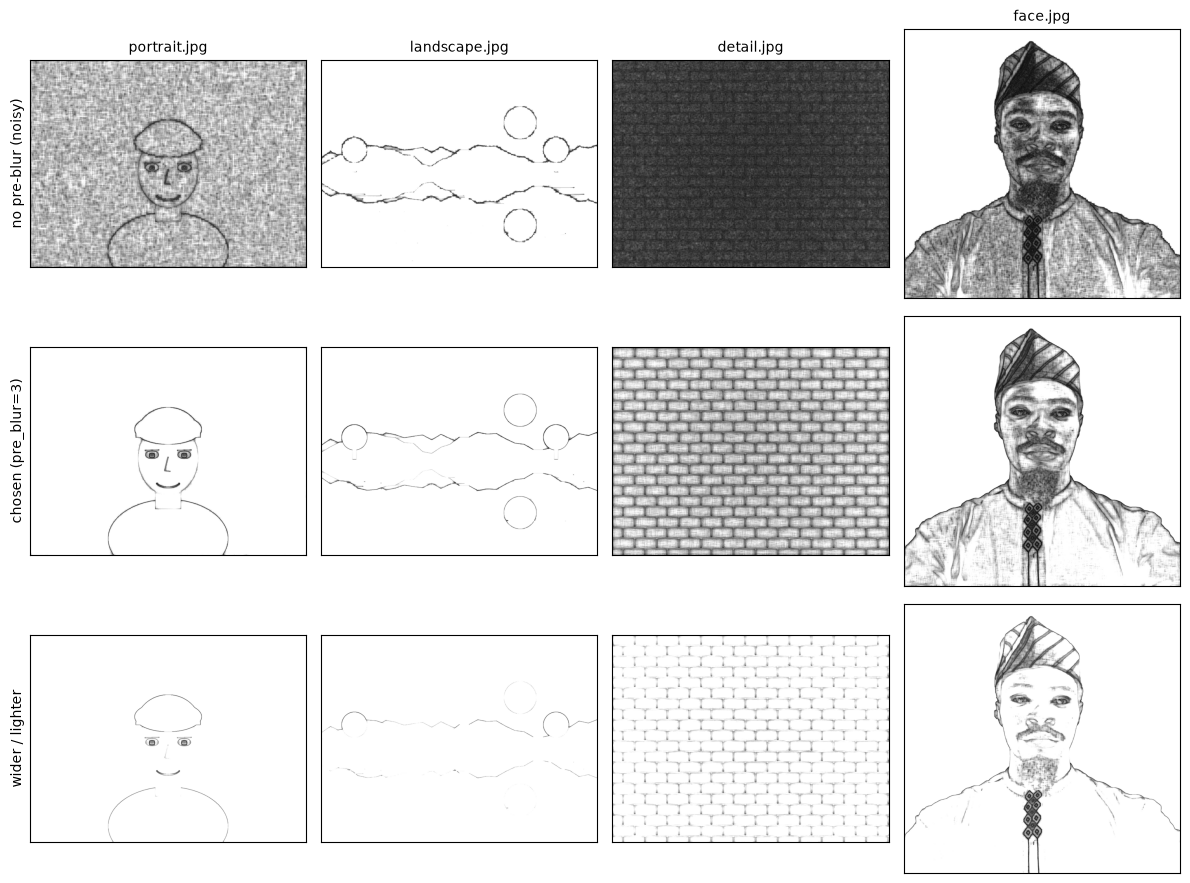

In [4]:
def pencil_sketch(img, sigma_s=40, sigma_r=0.15, shade_factor=0.02, pre_blur=3):
    if pre_blur:
        img = cv2.GaussianBlur(img, (pre_blur, pre_blur), 0)
    gray_sketch, _color_sketch = cv2.pencilSketch(img, sigma_s=sigma_s, sigma_r=sigma_r, shade_factor=shade_factor)
    return cv2.cvtColor(gray_sketch, cv2.COLOR_GRAY2BGR)

configs = {
    "no pre-blur (noisy)": dict(sigma_s=40, sigma_r=0.15, shade_factor=0.02, pre_blur=0),
    "chosen (pre_blur=3)": dict(sigma_s=40, sigma_r=0.15, shade_factor=0.02, pre_blur=3),
    "wider / lighter": dict(sigma_s=50, sigma_r=0.25, shade_factor=0.025, pre_blur=3),
}

rows = [[pencil_sketch(images[n], **params) for n in TEST_IMAGES] for params in configs.values()]
show_grid(rows, row_labels=list(configs.keys()), col_labels=TEST_IMAGES)


**Decision: `sigma_s=40, sigma_r=0.15, shade_factor=0.02`, with a 3x3 Gaussian
pre-blur.**

The pre-blur removes the speckle noise on the real photo. `sigma_r=0.15`
keeps strokes clean and readable without going so high that fine detail (like
the brick mortar lines in `detail.jpg`) disappears into flat white.

## 3. Cartoonify

Two independent pieces combined: a smoothed color layer, and a black edge
mask, ANDed together.

**Color layer** — repeated bilateral filtering (`cv2.bilateralFilter`). Unlike
a Gaussian blur, bilateral filtering smooths flat regions while leaving strong
edges alone, which is what gives cartoonify its "flat color, sharp outline"
look instead of just blurring everything. `d` is the neighborhood diameter,
`sigmaColor`/`sigmaSpace` control how much color difference / spatial distance
still counts as "the same region". Running it twice (`bilateral_iters=2`)
smooths more without needing an extreme single-pass radius.

**Edge layer** — grayscale, median blur, then `cv2.adaptiveThreshold` to get
black line edges. `blockSize` and `C` control edge sensitivity; `median_blur`
denoises before edge detection.

First pass produced good outlines on the synthetic images, but the real photo
had noise-driven flecks of black scattered across smooth skin. Increasing the
median blur before edge detection from 7 to 9, and adjusting the threshold
block size/C, cleared it out without dulling real edges like the jawline or
brick mortar.

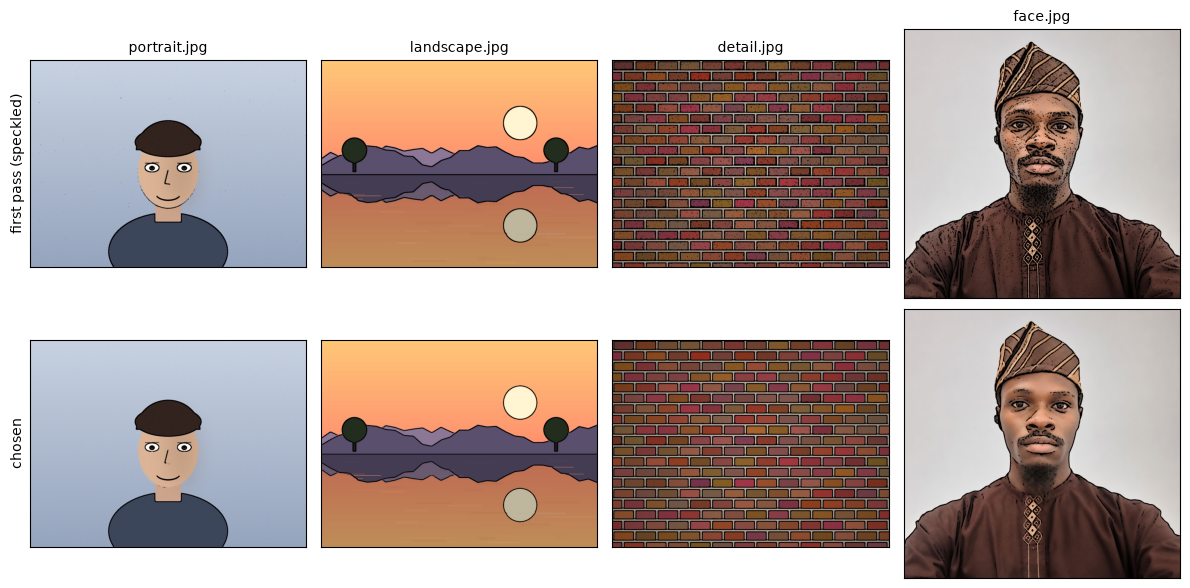

In [5]:
def cartoonify(img, d=9, sigma_color=75, sigma_space=75, bilateral_iters=2,
                block_size=9, C=4, median_blur=9):
    color = img.copy()
    for _ in range(bilateral_iters):
        color = cv2.bilateralFilter(color, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.medianBlur(gray, median_blur)
    edges = cv2.adaptiveThreshold(
        gray_blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,
        blockSize=block_size, C=C,
    )
    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    return cv2.bitwise_and(color, edges_bgr)

configs = {
    "first pass (speckled)": dict(block_size=9, C=2, bilateral_iters=2, median_blur=7),
    "chosen": dict(block_size=9, C=4, bilateral_iters=2, median_blur=9),
}

rows = [[cartoonify(images[n], **params) for n in TEST_IMAGES] for params in configs.values()]
show_grid(rows, row_labels=list(configs.keys()), col_labels=TEST_IMAGES)


**Decision: `bilateral_iters=2` (d=9, sigmaColor=75, sigmaSpace=75),
edge mask from `median_blur=9` then `adaptiveThreshold(blockSize=9, C=4)`.**

The extra median blur before edge detection was the actual fix — it was the
single biggest lever for cleaning up noise-driven edges on the real photo
while the brick mortar lines in `detail.jpg` stayed sharp.

## 4. Oil painting

`cv2.xphoto.oilPainting(img, size, dynRatio)` — only available via
`opencv-contrib-python`, not plain `opencv-python`. This is a known
repo-level dependency trade-off, flagged in `pyproject.toml` and the README.

- `size`: brush neighborhood radius. Bigger = broader, more abstracted
  strokes.
- `dynRatio`: color quantization ratio inside each neighborhood. Bigger =
  fewer distinct colors per region, chunkier look.

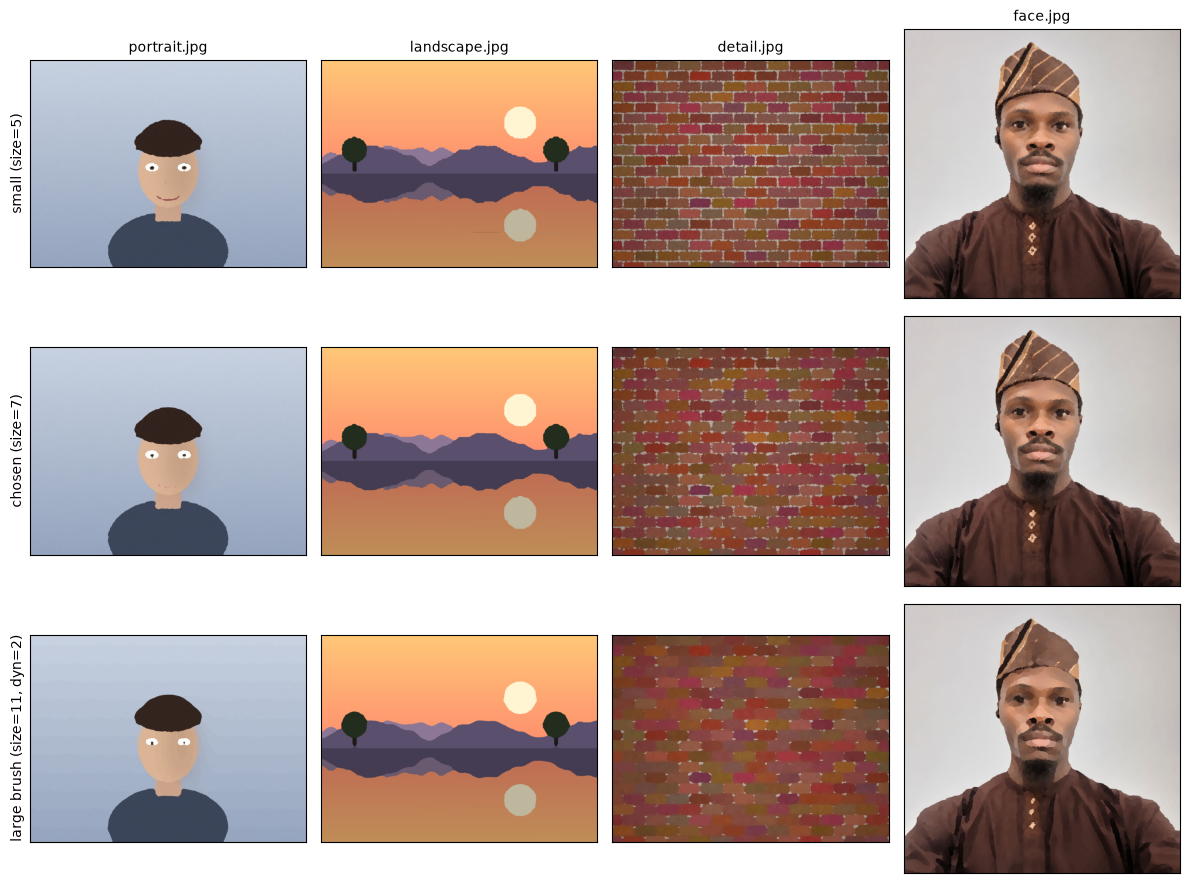

In [6]:
def oil_painting(img, size=7, dyn_ratio=1):
    return cv2.xphoto.oilPainting(img, size, dyn_ratio)

configs = {
    "small (size=5)": dict(size=5, dyn_ratio=1),
    "chosen (size=7)": dict(size=7, dyn_ratio=1),
    "large brush (size=11, dyn=2)": dict(size=11, dyn_ratio=2),
}

rows = [[oil_painting(images[n], **params) for n in TEST_IMAGES] for params in configs.values()]
show_grid(rows, row_labels=list(configs.keys()), col_labels=TEST_IMAGES)


**Decision: `size=7, dyn_ratio=1`.**

Large brush (`size=11, dyn_ratio=2`) looked more painterly but wiped out the
embroidery pattern on the shirt in `face.jpg` and the mortar lines in
`detail.jpg` entirely — too much loss of detail for a portfolio piece where
the input should still be recognizable. `size=7` keeps visible brush texture
while staying legible.

Known trade-off worth remembering for the README: oil painting is the
slowest of the 5 effects, since the brush-neighborhood computation scales
with image size. Large uploads may need client-side resizing first.

## 5. Pixel art

Downscale with `INTER_AREA` (averages blocks of pixels - the right choice
for shrinking, unlike `INTER_LINEAR` which is better suited to enlarging),
optionally quantize colors with k-means, then upscale back with
`INTER_NEAREST` (no interpolation, keeps hard pixel-block edges instead of
smoothing them back out).

- `block_size`: how many source pixels collapse into one "pixel" block.
  Bigger = chunkier/lower-res look.
- `k_colors`: k-means cluster count for color quantization. Fewer colors =
  more of a limited retro palette.

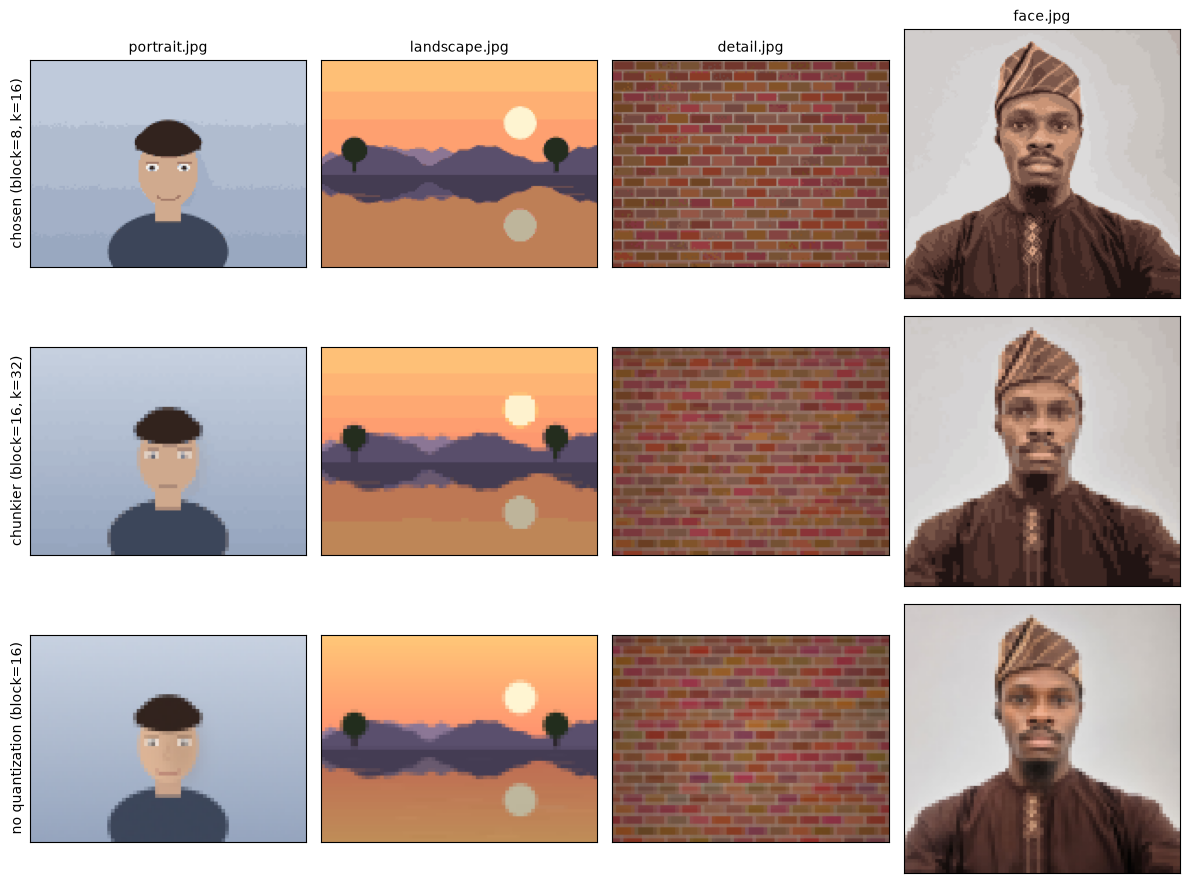

In [7]:
def pixel_art(img, block_size=8, k_colors=16):
    h, w = img.shape[:2]
    small = cv2.resize(img, (max(1, w // block_size), max(1, h // block_size)), interpolation=cv2.INTER_AREA)

    if k_colors:
        data = small.reshape(-1, 3).astype(np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.5)
        _, labels, centers = cv2.kmeans(data, k_colors, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)
        centers = centers.astype(np.uint8)
        small = centers[labels.flatten()].reshape(small.shape)

    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

configs = {
    "chosen (block=8, k=16)": dict(block_size=8, k_colors=16),
    "chunkier (block=16, k=32)": dict(block_size=16, k_colors=32),
    "no quantization (block=16)": dict(block_size=16, k_colors=None),
}

rows = [[pixel_art(images[n], **params) for n in TEST_IMAGES] for params in configs.values()]
show_grid(rows, row_labels=list(configs.keys()), col_labels=TEST_IMAGES)


**Decision: `block_size=8, k_colors=16`.**

No-quantization pixel art still looks smooth/gradient-y — technically blocky
but doesn't read as "pixel art" without a limited palette. `block_size=16`
with more colors just looks like a blurrier photo. `block_size=8, k=16`
is the sweet spot: clearly blocky, clearly a limited retro palette, still
recognizable as the source image.

## Locked-in parameters

These five functions, as written above with the chosen parameters, are what
gets extracted into `src/effects.py` in step 3 — same signatures
(`numpy.ndarray` in, `numpy.ndarray` out), just moved out of the notebook and
with the parameter sweeps stripped out.

| Effect | Final parameters |
|---|---|
| grayscale | CLAHE, `clip_limit=2.0`, `tile=8` |
| pencil_sketch | `sigma_s=40, sigma_r=0.15, shade_factor=0.02`, `pre_blur=3` |
| cartoonify | `bilateral_iters=2` (`d=9, sigmaColor=75, sigmaSpace=75`), edges `median_blur=9`, `adaptiveThreshold(blockSize=9, C=4)` |
| oil_painting | `size=7, dyn_ratio=1` (needs `opencv-contrib-python`) |
| pixel_art | `block_size=8, k_colors=16` |
